# LLM
- формирует JSON для вставки фигуры в базу данных

In [1]:
import matplotlib.pyplot as plt
from heandlers.pg_db import fetch_polygon, close_pool
import json
from heandlers import llm
from heandlers.pg_db import insert_polygon, init_pool_from_env, close_pool

/home/ranil/anaconda3/envs/axenix/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
peft_path = "/home/ranil/Рабочий стол/Axenix/task3/polygon-json-lora"
tokenizer, model = llm.create_tokenizer_model(peft_path)

Loading checkpoint shards: 100%|██████████| 2/2 [00:10<00:00,  5.18s/it]


# Промт в LLM

In [3]:
# Промт пользователя
PROMPT = "Привет! Я хочу, чтобы ты вставил в БД. Зелёный квадрат"

In [4]:
input_data = await llm.create_json_from_prompt(PROMPT, model, tokenizer, 4)
input_data

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{'name': 'Квадрат',
 'color': 'зеленый',
 'vertexes': [{'x': -1, 'y': -1, 'order': 1},
  {'x': 1, 'y': -1, 'order': 2},
  {'x': 1, 'y': 1, 'order': 3},
  {'x': -1, 'y': 1, 'order': 4}]}

# Вставка в БД

In [5]:
pool = await init_pool_from_env()

try:
    await insert_polygon(pool, polygon_data= input_data)
finally:
    await close_pool(pool)

# Чтение из БД

In [6]:
pool = await init_pool_from_env()
try:
    square = await fetch_polygon(pool, "Квадрат")
finally:
    await close_pool(pool)

# Отрисовка

In [7]:
def get_xy_from_vertexes(vertexes):
    sorted_vertexes = sorted(vertexes, key= lambda d : d['vertexorder'])
    x = []
    y = []
    for vertex in sorted_vertexes:
        x.append(vertex['x'])
        y.append(vertex['y'])
    return x, y

In [8]:
def translate_color(color_name,
                    config_path= 'data/colors.json'):
    with open(config_path) as file:
        RU_TO_EN_COLOR = json.load(file)
    color = color_name.strip().lower()

    if color not in RU_TO_EN_COLOR:
        raise ValueError(f"Не могу обработать цвет: {color_name}")
    return RU_TO_EN_COLOR[color]

In [9]:
def draw(polygons):
    plt.figure(figsize= (10, 12))
    for polygon in polygons:
        name = polygon['polygon_name']
        color = polygon['color_name']
        x, y = get_xy_from_vertexes(polygon['vertexes'])
        x.append(x[0])
        y.append(y[0])
        plt.plot(x, y, label= name, color= translate_color(color))
    plt.title("Фигуры")

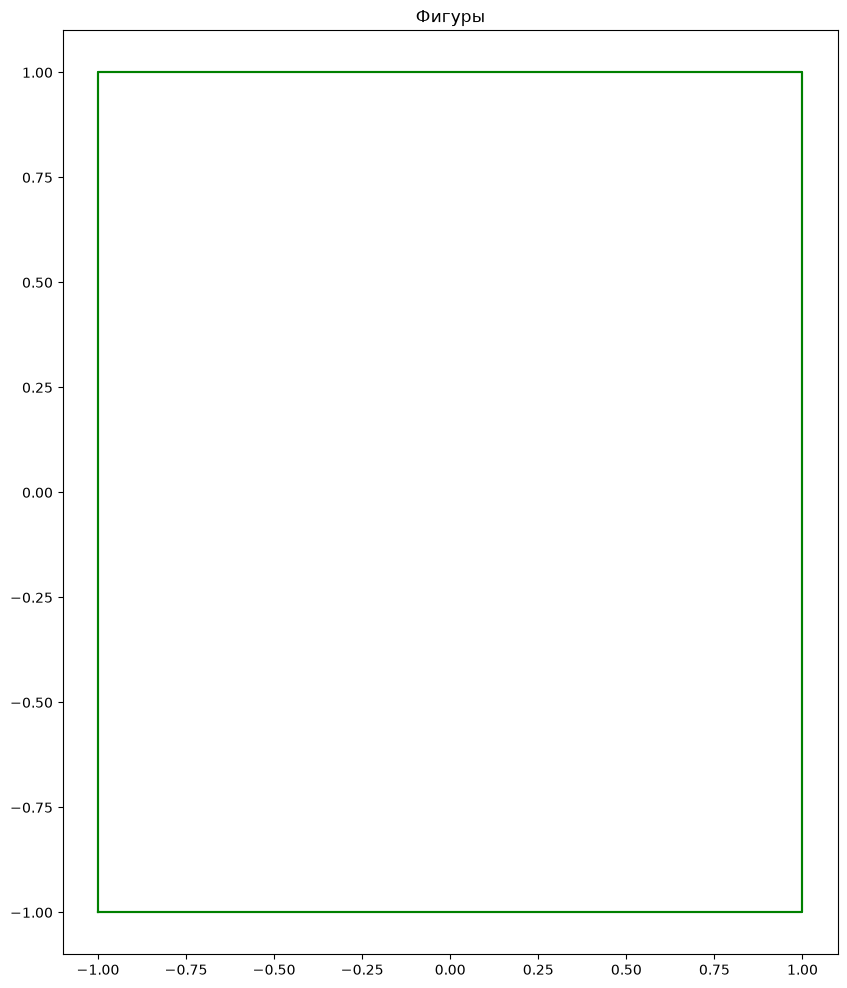

In [10]:
draw(square)